<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4psy_2023/blob/main/kl.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>

(loo_notebook)=
# Validazione Incrociata Leave-One-Out

```{admonition} Obiettivi di apprendimento
Dopo aver completato questo capitolo, acquisirete le competenze per:

- comprendere il concetto di Validazione Incrociata Leave-One-Out;
- calcolare LOO-CV usando PyC;
- usare LOO-CV nel confronto tra modelli;
- comprendere il concetto di valore diagnostico Pareto $k$;
- calcolare i valori diagnostici Pareto $k$ con PyMC.
```

In questo capitolo approfondiremo il concetto di stima della Densità Predittiva Logaritmica Attesa (ELPD), un parametro cruciale per valutare l'efficacia di un modello statistico nell'effettuare previsioni accurate. La ELPD si concentra sulla qualità delle previsioni di un modello, considerando il suo comportamento di fronte a nuovi dati non ancora osservati. Questo è di particolare importanza perché un modello che si adatta perfettamente ai dati passati potrebbe non essere altrettanto efficace nel prevedere eventi futuri o nuove osservazioni.

Tra i vari metodi disponibili per stimare la ELPD, uno dei più affidabili e comunemente utilizzati è la validazione incrociata Leave-One-Out (LOO-CV). Questa tecnica offre un approccio sistematico e rigoroso per valutare la capacità predittiva di un modello statistico. La LOO-CV si distingue per il suo approccio unico: anziché utilizzare l'intero set di dati per adattare il modello e valutarne le prestazioni, essa rimuove una singola osservazione alla volta dal set di dati, adatta il modello ai dati rimanenti, e quindi valuta la sua capacità di prevedere l'osservazione esclusa. Questo processo viene ripetuto per ogni osservazione nel set di dati, fornendo una valutazione completa e dettagliata della capacità del modello di generalizzare oltre i dati osservati.

La LOO-CV si rivela particolarmente utile quando i dati sono limitati o quando ogni singola osservazione è preziosa per comprendere il fenomeno studiato. Utilizzando questo metodo, possiamo ottenere una visione più chiara e realistica della capacità predittiva del modello, il che è essenziale per applicazioni pratiche e decisioni basate sui dati.

In questo capitolo, esamineremo nel dettaglio la metodologia della LOO-CV, discutendo come essa possa essere implementata per stimare la ELPD. Esamineremo anche i suoi vantaggi e le sfide associate, fornendo esempi pratici e linee guida su come utilizzare efficacemente questo metodo nella valutazione dei modelli statistici.

In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.graphics import tsaplots
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import pymc.sampling_jax
from scipy.stats import beta
from scipy.integrate import quad
import arviz as az

/Users/corrado/opt/anaconda3/envs/pymc_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")
sns.set_theme(palette="colorblind")

In [3]:
# We can control the number cores that are used by an environment variable:
import os
import multiprocessing

num_cores = multiprocessing.cpu_count()
os.environ["RAYON_NUM_THREADS"] = str(num_cores)

## Terminologia

In questa sezione, esamineremo alcuni concetti chiave nel contesto della valutazione dei modelli statistici:

- **Accuratezza sul campione interno** (within-sample accuracy): Misura dell'accuratezza del modello calcolata utilizzando gli stessi dati utilizzati per addestrare il modello.
- **Accuratezza sul campione esterno** (out-of-sample accuracy): Misura dell'accuratezza del modello calcolata utilizzando dati non utilizzati durante l'addestramento del modello.

Generalmente, l'accuratezza sul campione interno risulterà più alta rispetto all'accuratezza sul campione esterno. Questo fenomeno porta spesso a una sovrastima delle capacità del modello quando viene valutato utilizzando solo l'accuratezza sul campione interno. Pertanto, l'utilizzo dell'accuratezza sul campione esterno è consigliato per una valutazione più accurata delle prestazioni del modello. Tuttavia, l'esclusione di dati per la valutazione esterna comporta una riduzione delle informazioni disponibili per addestrare i modelli, il che può essere problematico in contesti in cui i dati sono limitati.

Per affrontare questa problematica, sono stati sviluppati due approcci principali:

- **Criteri di informazione**: Questo termine generico si riferisce a diverse formule che approssimano l'accuratezza sul campione esterno come l'accuratezza sul campione interno più un termine di penalizzazione per la complessità del modello.
- **Validazione incrociata**: Questo approccio è empirico e si basa sulla suddivisione dei dati disponibili in sottoinsiemi separati, utilizzati alternativamente per l'addestramento e la valutazione del modello.

## Criteri d'Informazione

I criteri di informazione sono strumenti essenziali per valutare e confrontare i modelli statistici, bilanciando l'adattamento dei dati con la complessità del modello. Questi criteri si basano sui principi della teoria dell'informazione, che fornisce un quadro per quantificare la quantità di informazione che un modello può catturare sui dati osservati. 

### Errore Quadratico Medio

Il criterio di informazione più semplice è l'errore quadratico medio. L'errore quadratico medio è una misura comunemente usata per quantificare la discrepanza tra i valori osservati e quelli predetti da un modello, calcolando la media delle differenze al quadrato. Questo metodo enfatizza gli errori più grandi, fornendo una penalità più forte per le previsioni inesatte. Matematicamente, si esprime come:

$$
\frac{1}{n} \sum_{i=1}^{n} (y_i - E(y_i \mid \theta))^2,
$$

dove $y_i$ rappresenta i valori osservati, $E(y_i \mid \theta)$ i valori predetti dal modello con parametri $\theta$, e $n$ il numero totale di osservazioni.

### La Somma dei Logaritmi delle Verosimiglianze

In un contesto probabilistico, è più appropriato usare la somma dei logaritmi delle verosimiglianze che considera la probabilità di osservare i dati dati i parametri del modello:

$$
\sum \log p(y_i \mid \theta).
$$

Quando la distribuzione assunta è gaussiana, questa somma è proporzionale all'errore quadratico medio, collegando concettualmente la somma dei logaritmi delle verosimiglianze all'errore quadratico medio.

### Criterio di Informazione di Akaike (AIC)

L'Information Criterion (AIC) è una metrica ampiamente utilizzata per la selezione dei modelli, poiché bilancia efficacemente la capacità predittiva di un modello con la sua complessità. Si definisce come:

$$
\text{AIC} = -2 \sum \log p(y_i \mid \hat{\theta}_{\text{mle}}) + 2k,
$$

dove $\hat{\theta}_{\text{mle}}$ indica la stima di massima verosimiglianza dei parametri, e $k$ è il numero di parametri stimati. L'AIC penalizza i modelli con un maggior numero di parametri, promuovendo così la parsimonia. Valori minori di AIC indicano una migliore capacità predittiva del modello e una migliore adattabilità ai dati. Un valore di AIC pari a 0 non è comune e può indicare che il modello è perfettamente adattato ai dati, ma si verifica solo in circostanze ideali.

### Widely Applicable Information Criterion

Il Widely Applicable Information Criterion (WAIC) è una generalizzazione bayesiana dell'AIC, che tiene conto dell'intera distribuzione a posteriori dei parametri. È formulato come:

$$
\text{WAIC} = -2\left[ \sum_{i=1}^{n} \log \left( \frac{1}{S} \sum_{s=1}^{S} p(y_i|\theta^{(s)}) \right) - \sum_{i=1}^{n} \text{Var}_{\theta^{(s)}} \left( \log p(y_i|\theta^{(s)}) \right) \right],
$$

dove $S$ rappresenta il numero di campioni nella distribuzione a posteriori, e $\text{Var}_{\theta^{(s)}}$ indica la varianza calcolata sulla log-verosimiglianza. Il primo termine è simile al criterio di Akaike, tranne che viene valutato per tutte le osservazioni e tutti i campioni della distribuzione a posteriori. Il secondo termine è un po' più difficile da giustificare senza entrare nei dettagli tecnici, ma può essere interpretato come il numero effettivo di parametri. Ciò che è importante da un punto di vista pratico è che WAIC utilizza l'intera distribuzioni a posteriori (e non una stima puntuale) per il calcolo di entrambi i termini, quindi WAIC può essere applicato a qualsiasi modello bayesiano. 

In sintesi, sia l'AIC che il WAIC forniscono delle metriche per la selezione dei modelli, offrendo un compromesso tra l'adattamento dei dati e la semplicità del modello. Mentre l'AIC è più comunemente usato in contesti non bayesiani, il WAIC è maggiormente usato in un framework bayesiano.

## Validazione Incrociata

La validazione incrociata rappresenta un metodo robusto ed efficiente per la valutazione comparativa di diversi modelli predittivi. Questo approccio implica la divisione del set di dati in K segmenti, o "fold", mirando a garantire la loro omogeneità sia in termini di dimensioni che, dove possibile, rispetto ad altre caratteristiche quali la distribuzione delle classi. In ogni ciclo di validazione incrociata, si addestra il modello utilizzando K-1 fold, mentre il fold restante viene impiegato come set di test. Questo procedimento si ripete, alternando sistematicamente il fold escluso dall'addestramento e utilizzandolo per la valutazione, fino al completamento dei K cicli di addestramento e valutazione. La precisione del modello è quindi determinata dalla media delle precisioni ottenute in ciascun ciclo, in un processo noto come validazione incrociata K-fold. Al termine della validazione incrociata, si procede con un ulteriore addestramento del modello su tutto il dataset per ottenere la versione definitiva del modello, destinata a predizioni o ad altri scopi. Nel caso specifico in cui K corrisponda al numero totale di osservazioni, si parla di validazione incrociata Leave-One-Out (LOOCV), caratterizzata dall'addestramento del modello su tutti i dati ad eccezione di uno per volta.

Sebbene semplice nell'idea, la validazione incrociata può rivelarsi computazionalmente onerosa per certi modelli o dataset di grandi dimensioni, spingendo la ricerca verso alternative meno dispendiose, come i Criteri di Informazione. Proseguiremo discutendo un approccio per approssimare la validazione incrociata basandosi su un unico addestramento completo sul dataset.

## Approssimazione della Validazione Incrociata

L'approssimazione della validazione incrociata, in particolare per varianti computazionalmente esigenti quali la LOOCV, offre un significativo vantaggio. È possibile estimare i risultati della validazione incrociata sfruttando le informazioni ottenute da un singolo addestramento sull'intero set di dati. Questo metodo è conosciuto come "Pareto Smoothed Importance Sampling Leave-One-Out Cross-Validation" (PSIS-LOOCV), comunemente abbreviato in LOO. In questo contesto, ciò che cerchiamo di calcolare è espresso dall'equazione seguente:

$$
\text{ELPD} = \int_{\tilde{y}} p_{t}(\tilde{y}) \log p(\tilde{y} \mid y) \, \mathrm{d}\tilde{y} .
$$

Questa formula ci illumina su tre concetti chiave:

1. **Enfasi sui Dati Futuri**: L'ELPD impiega $\tilde{y}$ per simboleggiare i dati futuri potenzialmente osservabili, differenziandosi dall'uso di $y$ per i dati già raccolti.

2. **Impiego della Distribuzione Predittiva Posteriore**: Qui, $p(\tilde{y} \mid y)$ rappresenta la distribuzione predittiva posteriore, che fornisce stime delle future osservazioni del modello basate sui dati pregressi $y$, distaccandosi dalla considerazione di un modello probabilistico focalizzato sui dati esistenti.

3. **Il Ruolo di $p_t$**: Presente in entrambe le formulazioni, $p_t$ denota la distribuzione reale dei dati. Mentre nella divergenza di Kullback-Leibler valuta l'adeguatezza del modello ai dati osservati, nell'ELPD misura l'efficacia delle previsioni future del modello rispetto alla realtà.

In conclusione, la *Densità Logaritmica Predittiva Attesa* (ELPD) si rivela uno strumento fondamentale per valutare l'abilità predittiva di un modello, privilegiando le previsioni su nuovi dati piuttosto che l'adattamento a quelli già noti. Questo si contrappone alla misurazione dell'adattamento del modello mediante la divergenza $\mathbb{KL}$, sottolineando l'importanza di valutare la capacità di un modello di generalizzare oltre i dati attuali.

### Sfide nella Stima della Densità Logaritmica Predittiva Attesa (ELPD)

Una delle principali difficoltà nella stima della Densità Logaritmica Predittiva Attesa (ELPD) deriva dal fatto che la distribuzione di probabilità reale dei dati, indicata con $p_t$, è generalmente ignota. Questa incognita rende la determinazione esatta dell'ELPD impraticabile. Nonostante ciò, è possibile ottenere una stima affidabile dell'ELPD attraverso l'impiego di metodologie specifiche.

Sebbene non si possa definire con precisione assoluta la distribuzione predittiva posteriore $p(\tilde{y} \mid y)$ mediante un'espressione analitica esatta, è fattibile approssimarla ricorrendo a tecniche di simulazione. L'ELPD incorpora il termine $p_t(\tilde{y})$, che si riferisce alla distribuzione dei futuri dati potenziali secondo la concezione del modello "reale". Data l'impossibilità di conoscere a priori questa distribuzione, possiamo soltanto stimare l'ELPD anziché calcolarla direttamente. Di seguito, esploreremo le strategie per una stima efficace dell'ELPD, basandoci su un insieme di dati osservati.

### Un Esempio Empirico

Per comprenderne meglio il funzionamento dell'ELPD, esaminiamo un esempio tratto dal testo [Bayesian Data Analysis for Cognitive Science](https://vasishth.github.io/bayescogsci/book/expected-log-predictive-density-of-a-model.html), in cui questa quantità viene calcolata sia in forma esatta che approssimata.

Supponiamo di avere un campione di $n$ osservazioni e di conoscere il vero processo generativo dei dati, rappresentato dalla distribuzione $p_t(y) = Beta(1, 3).$ Da questo campione, generato in modo artificiale, ad esempio tramite

In [4]:
np.random.seed(75)

# Number of samples
n = 10000

# Draw samples from a Beta distribution
y_data = np.random.beta(1, 3, n)
print(y_data[:6])

[0.21810354 0.05532253 0.13545025 0.42102514 0.14728608 0.11052926]


abbiamo adattato un modello bayesiano $\mathcal{M}$ e ottenuto la distribuzione a posteriori per i parametri del modello descritta da $p(y^{rep} \mid y) \sim Beta(2, 2).$

L'ELPD si calcola con l'integrazione:

$$
\text{ELPD} = \int_{y^{rep}}p_{t}(y^{rep})\log p(y^{rep} \mid y) \,\operatorname {d}\!y^{rep}.
$$

Svolgendo i calcoli otteniamo:

In [5]:
# True distribution
def p_t(y):
    return beta.pdf(y, 1, 3)

# Predictive distribution
def p(y):
    return beta.pdf(y, 2, 2)

# Integration
def integrand(y):
    return p_t(y) * np.log(p(y))

# Perform numerical integration
result, error = quad(integrand, 0, 1)

print(result)

-0.37490719743844486


In pratica, non conoscendo $p_t(y)$, approssimiamo l'ELPD usando l'eq. {eq}`eq-elpd`:

$$
\frac{1}{n} \sum_{i=1}^n \log p(y_i \mid y).
$$ (eq-empirical-elpd)

Questo metodo è un'approssimazione Monte Carlo basata sui dati osservati, usando $\{y_1, y_2, \ldots, y_n\}$ come rappresentazione empirica di possibili futuri dati.

Esaminiamo in dettaglio le componenti dell'eq. {eq}`eq-empirical-elpd`:

1. **Densità Logaritmica Predittiva $ \log p(y_i \mid y) $ per un dato $ y_i $**: Questa misura valuta quanto efficacemente il modello predice un singolo dato $y_i$, data la distribuzione osservata $y$. Valori più alti indicano una migliore performance predittiva.
2. **Media della Densità Logaritmica Predittiva**: La media di questi valori logaritmici predittivi fornisce una stima complessiva dell'efficacia predittiva del modello sull'intero set di dati.

Nel caso dell'esempio in discussione, usando l'eq. {eq}`eq-empirical-elpd` otteniamo un valore approssimato a quello trovato in precedenza:

In [6]:
1 / n * np.sum(np.log(p(y_data)))

-0.3721938430299501

L'ELPD funge da misura complessiva dell'efficacia di un modello nel prevedere dati non ancora osservati. Un valore elevato dell'ELPD suggerisce una maggiore efficacia del modello in termini di previsioni accurate. Tuttavia, è essenziale riconoscere che l'ELPD è una stima basata sui dati attualmente disponibili; la sua affidabilità può essere compromessa se i dati futuri si discostano significativamente da quelli su cui si basa la stima.

### Un Secondo Esempio Empirico

Generiamo un set di dati artificiali seguendo una distribuzione normale con una media (`loc`) di 5 e una deviazione standard (`scale`) di 2. Scegliamo una dimensione (`size`) del campione di 100.

In [7]:
SEED = 42  # Scegli un valore per il seed
np.random.seed(SEED)

data = np.random.normal(loc=5, scale=2, size=100)
print(data)

[ 5.99342831  4.7234714   6.29537708  8.04605971  4.53169325  4.53172609
  8.15842563  6.53486946  4.06105123  6.08512009  4.07316461  4.06854049
  5.48392454  1.17343951  1.55016433  3.87542494  2.97433776  5.62849467
  3.18395185  2.1753926   7.93129754  4.5484474   5.13505641  2.15050363
  3.91123455  5.22184518  2.69801285  5.75139604  3.79872262  4.4166125
  3.79658678  8.70455637  4.97300555  2.88457814  6.64508982  2.5583127
  5.41772719  1.08065975  2.3436279   5.39372247  6.47693316  5.34273656
  4.76870344  4.39779261  2.04295602  3.56031158  4.07872246  7.11424445
  5.68723658  1.47391969  5.64816794  4.22983544  3.646156    6.22335258
  7.06199904  6.86256024  3.32156495  4.38157525  5.66252686  6.95109025
  4.04165152  4.62868205  2.78733005  2.60758675  6.62505164  7.71248006
  4.85597976  7.0070658   5.72327205  3.70976049  5.72279121  8.07607313
  4.92834792  8.12928731 -0.23949021  6.64380501  5.17409414  4.4019853
  5.18352155  1.02486217  4.56065622  5.71422514  7.95

Utilizziamo PyMC per adattare un modello normale ai dati. Stimiamo la media (`mu`) e la deviazione standard (`sigma`) del modello attraverso il campionamento.

In [8]:
with pm.Model() as model:
    mu = pm.Normal("mu", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)
    y = pm.Normal("y", mu=mu, sigma=sigma, observed=data)
    # Sampling from the posterior
    # trace = pm.sampling_jax.sample_numpyro_nuts(1000)
    trace = pm.sample(nuts_sampler='nutpie', target_accept=0.95)
    # Generating posterior predictive samples
    trace = pm.sample_posterior_predictive(trace, extend_inferencedata=True)

Sampling: [y]


#### Una Singola Osservazione

Generiamo la distribuzione predittiva a posteriori per la variabile `y` e visualizziamo questa distribuzione per la prima osservazione (`y_i`) del campione.

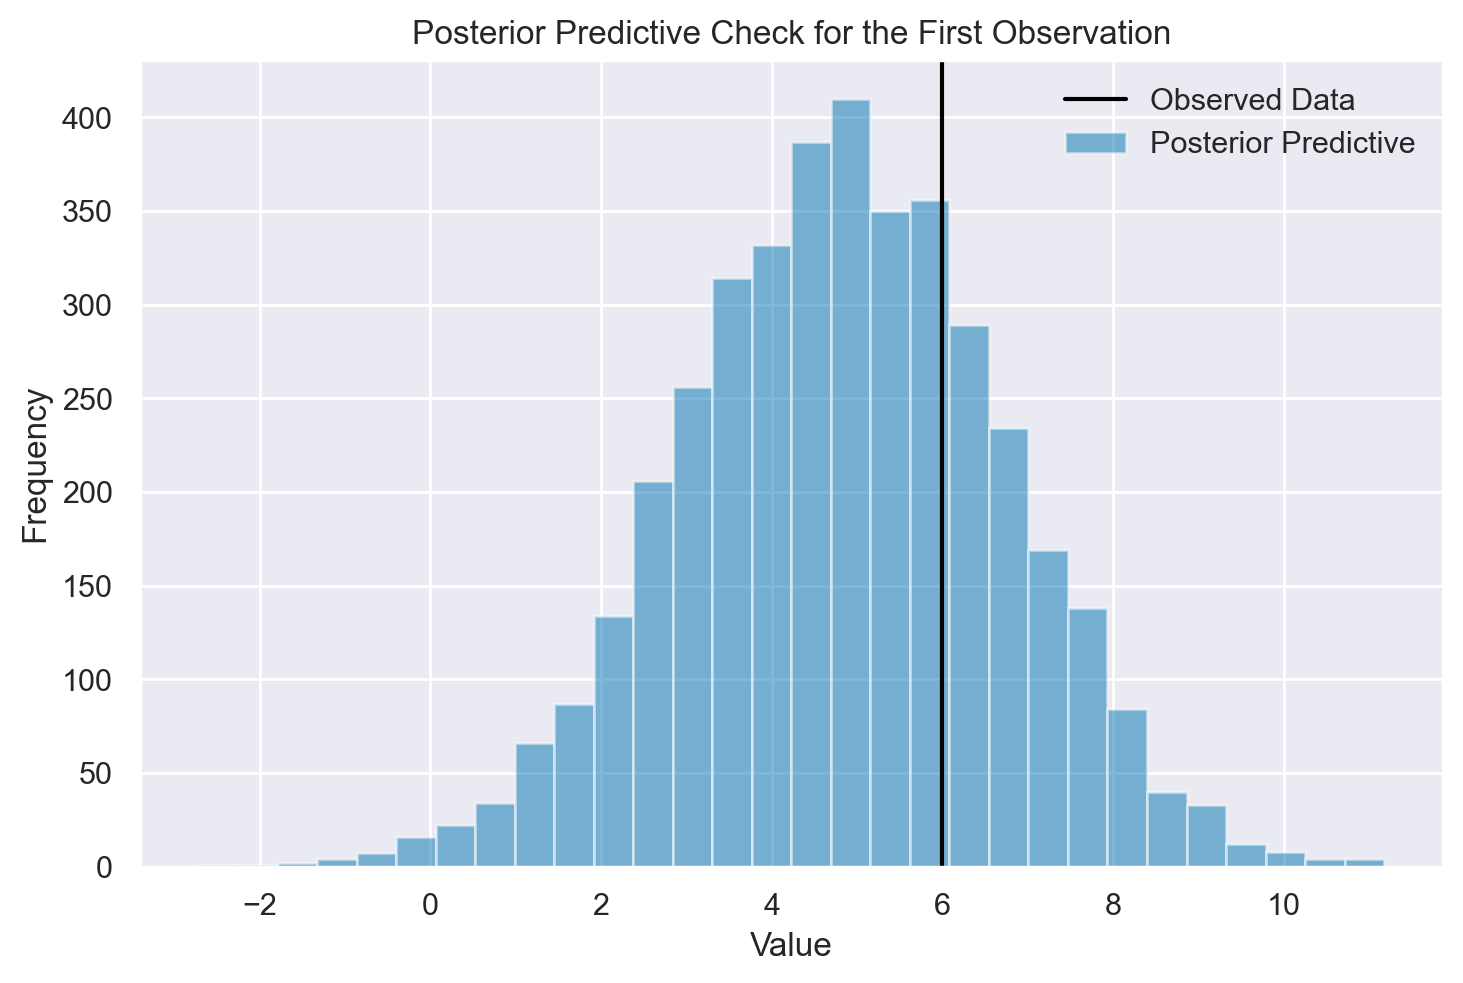

In [9]:
post_pred = trace.posterior_predictive
y_i_post_pred = post_pred["y"].values[:, :, 0]

plt.hist(y_i_post_pred.flatten(), bins=30, alpha=0.5)
plt.axvline(data[0], color="black")
plt.title("Posterior Predictive Check for the First Observation")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend(["Observed Data", "Posterior Predictive"])
plt.show()

Per la prima osservazione, calcoliamo il valore della funzione di densità di probabilità (PDF) utilizzando ogni coppia di parametri `mu` e `sigma` dalla distribuzione posteriore. Convertiamo poi questi valori della PDF in logaritmi e calcoliamo la media di questi logaritmi. Questo fornisce una stima empirica della ELPD per la prima osservazione.

Selezione della prima osservazione:

In [10]:
y_i = data[0]
y_i

5.993428306022466

Estrazione dei parametri dal campione posteriore:

In [11]:
mu_samples = trace.posterior["mu"].values.flatten()
mu_samples[0:10]

array([4.59616427, 4.63158923, 4.86696154, 4.47766139, 4.56673409,
       4.71682137, 5.03344646, 4.99571543, 5.01963387, 4.59821845])

In [12]:
sigma_samples = trace.posterior["sigma"].values.flatten()
sigma_samples[0:10]

array([1.64995887, 1.61510928, 1.74590161, 1.60647579, 1.64692946,
       1.83172594, 1.95894806, 1.86542774, 1.90575641, 1.7960101 ])

Calcolo della densità di probabilità per ogni coppia di parametri:

In [13]:
pdf_values = [
    stats.norm.pdf(y_i, mu, sigma) for mu, sigma in zip(mu_samples, sigma_samples)
]

pdf_values[0:5]

[0.16893107409664937,
 0.17311082614548934,
 0.18556403778625138,
 0.15911772032975516,
 0.1664487956689038]

Calcolo del logaritmo delle densità:

In [14]:
log_pdf_values = np.log(pdf_values)
log_pdf_values[0:5]

array([-1.77826449, -1.75382328, -1.68435524, -1.83811097, -1.79306755])

Calcolo della media dei valori logaritmici:

In [15]:
mean_log_density = np.mean(log_pdf_values)
mean_log_density

-1.7485982708467573

Questo calcolo ci fornisce una stima empirica della media della densità logaritmica predittiva (ELPD) per la prima osservazione del campione.

#### Estensione a Tutte le Osservazioni

Ripetiamo il processo per ogni osservazione nel set di dati. Calcoliamo la densità logaritmica predittiva per ogni osservazione utilizzando lo stesso metodo usato per la prima osservazione. Infine, calcoliamo la media di tutte queste densità logaritmiche predittive. Questo valore rappresenta la stima della ELPD per l'intero set di dati.

In [16]:
# Calcolo della densità logaritmica predittiva per ogni osservazione
all_log_densities = []
for y_i in data:
    pdf_values = [
        stats.norm.pdf(y_i, mu, sigma) for mu, sigma in zip(mu_samples, sigma_samples)
    ]
    log_pdf_values = np.log(pdf_values)
    mean_log_density = np.mean(log_pdf_values)
    all_log_densities.append(mean_log_density)

In [17]:
# Calcolo della media su tutte le osservazioni
overall_mean_log_density = np.mean(all_log_densities)
overall_mean_log_density

-2.0210787574152023

## Validazione Incrociata Leave-One-Out per la Stima dell'ELPD

Per stimare l'Expected Log Predictive Density (ELPD), un approccio efficace e consolidato è rappresentato dalla validazione incrociata Leave-One-Out (LOO-CV). Questo metodo permette di valutare con precisione la capacità di un modello di fare previsioni accurate. La LOO-CV si articola in una serie di passaggi sistematici:

1. **Esclusione di un'osservazione**: Inizialmente, si rimuove una singola osservazione dal set di dati.
2. **Adattamento del Modello ai Dati Residui**: Successivamente, il modello viene adattato utilizzando il set di dati ridotto, escludendo l'osservazione rimossa.
3. **Valutazione delle Previsioni del Modello**: Si procede poi a valutare la capacità del modello di prevedere l'osservazione che è stata esclusa.
4. **Iterazione per Ogni Osservazione e Calcolo della Media**: Questo processo viene ripetuto per ogni singola osservazione nel set di dati. Per ciascuna iterazione, si calcola il valore logaritmico predittivo e si ottiene alla fine una media di questi valori, che fornisce una stima complessiva dell'ELPD attraverso la LOO-CV.

La LOO-CV si distacca dalla semplice media della densità logaritmica predittiva (LPD) per il suo approccio unico alla valutazione:

- **Media della LPD**: Questo metodo valuta la capacità predittiva del modello sull'intero set di dati, basandosi sulla probabilità complessiva assegnata dal modello ai dati osservati.
  
- **LOO-CV**: A differenza della media della LPD, la LOO-CV fornisce una misura più dettagliata e generalizzabile della capacità predittiva del modello. Attraverso l'esclusione e la valutazione di ciascuna osservazione individualmente, la LOO-CV verifica la robustezza e la capacità di generalizzazione del modello, offrendo una stima realistica di come potrebbe comportarsi nel prevedere nuovi dati.

In conclusione, mentre la media della LPD offre una valutazione generale basata sull'intero set di dati, la LOO-CV fornisce una visione più approfondita e generalizzabile, valutando la capacità del modello di adattarsi e prevedere con precisione nuovi dati. Questo approccio rende la LOO-CV uno strumento prezioso per una valutazione accurata delle prestazioni predittive dei modelli statistici.

## Un Esempio Empirico

Esaminiamo il calcolo di LOO-CV per i dati dell'esempio usato nel capitolo precedente. Iniziamo a calcolare la log-verosimiglianza.

In [18]:
SEED = 42  # Scegli un valore per il seed
np.random.seed(SEED)
data = np.random.normal(loc=5, scale=2, size=100)
print(data)

[ 5.99342831  4.7234714   6.29537708  8.04605971  4.53169325  4.53172609
  8.15842563  6.53486946  4.06105123  6.08512009  4.07316461  4.06854049
  5.48392454  1.17343951  1.55016433  3.87542494  2.97433776  5.62849467
  3.18395185  2.1753926   7.93129754  4.5484474   5.13505641  2.15050363
  3.91123455  5.22184518  2.69801285  5.75139604  3.79872262  4.4166125
  3.79658678  8.70455637  4.97300555  2.88457814  6.64508982  2.5583127
  5.41772719  1.08065975  2.3436279   5.39372247  6.47693316  5.34273656
  4.76870344  4.39779261  2.04295602  3.56031158  4.07872246  7.11424445
  5.68723658  1.47391969  5.64816794  4.22983544  3.646156    6.22335258
  7.06199904  6.86256024  3.32156495  4.38157525  5.66252686  6.95109025
  4.04165152  4.62868205  2.78733005  2.60758675  6.62505164  7.71248006
  4.85597976  7.0070658   5.72327205  3.70976049  5.72279121  8.07607313
  4.92834792  8.12928731 -0.23949021  6.64380501  5.17409414  4.4019853
  5.18352155  1.02486217  4.56065622  5.71422514  7.95

In [19]:
with pm.Model() as model:
    mu = pm.Normal("mu", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)
    y = pm.Normal("y", mu=mu, sigma=sigma, observed=data)
    # Sampling from the posterior
    # trace = pm.sampling_jax.sample_numpyro_nuts(1000)
    trace = pm.sample(nuts_sampler='nutpie', target_accept=0.95)
    # Generating posterior predictive samples
    trace = pm.sample_posterior_predictive(trace, extend_inferencedata=True)

Sampling: [y]


In [20]:
with model:
    pm.compute_log_likelihood(trace)

Ora usiamo la funzione `loo()` del pacchetto Arviz per calcolare LOO-CV:

In [21]:
loo_result = az.loo(trace, pointwise=True)
print(loo_result)

Computed from 4000 posterior samples and 100 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -203.01     6.80
p_loo        1.84        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)      100  100.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



Il valore di `overall_mean_log_density` che abbiamo calcolato precedentemente, pari a -2.0209, non è direttamente paragonabile al valore di `elpd_loo`, che è di -203.06, a causa delle differenze significative nelle loro scale e nei metodi di calcolo. Questa distinzione è importante da comprendere per una corretta interpretazione dei risultati.

Per iniziare, `overall_mean_log_density` rappresenta la media aritmetica dei logaritmi delle densità predittive per ogni singola osservazione nel set di dati. Questo valore si concentra su una stima media dell'adattamento del modello a ciascuna osservazione individualmente.

D'altra parte, `elpd_loo`, ovvero l'Expected Log Predictive Density calcolato tramite la validazione incrociata Leave-One-Out, fornisce una stima globale dell'adattamento del modello. Questo valore tiene conto non solo dell'adattamento del modello ai dati esistenti, ma anche della sua capacità di generalizzare e fare previsioni accurate su nuove osservazioni. Il calcolo di `elpd_loo` incorpora un'analisi più complessa, considerando l'effetto di rimuovere ogni osservazione dal set di dati e valutando la capacità predittiva del modello in queste condizioni.

Nonostante queste differenze, in entrambi i casi valori più elevati (cioè meno negativi) sono indicatori di prestazioni migliori. Tuttavia, a causa delle differenze nei loro metodi di calcolo e nell'interpretazione, non è possibile trasformare direttamente il valore di `overall_mean_log_density` in `elpd_loo` o viceversa. Sono due misure distinte che offrono prospettive diverse sull'adattamento e le capacità predittive del modello, e dovrebbero essere considerate complementari piuttosto che direttamente comparabili.

In conclusione, mentre la media della LPD fornisce una valutazione della performance del modello basata sull'intero set di dati, la LOO-CV offre una prospettiva più rigorosa e generalizzabile sulla capacità predittiva del modello. È importante notare che strumenti come PyMC e Arviz facilitano il calcolo della LOO-CV, specialmente in scenari che coinvolgono l'utilizzo di tecniche di campionamento MCMC. Questi strumenti possono semplificare notevolmente l'analisi in contesti di statistica bayesiana.

## Valori Diagnostici Pareto $k$ in LOO-CV

I valori diagnostici Pareto $k$ giocano un ruolo cruciale nell'analizzare l'affidabilità della stima dell'ELPD ottenuta tramite la LOO-CV. Questi valori sono indicatori chiave della precisione con cui la LOO-CV approssima l'ELPD. In altre parole, il valore Pareto $k$ ci aiuta a comprendere quanto la stima dell'ELPD, ottenuta tramite il processo LOO-CV, sia vicina al valore reale dell'ELPD che avremmo ottenuto se avessimo potuto calcolarlo direttamente senza approssimazioni.

Quando utilizziamo la LOO-CV, stiamo cercando di stimare come un modello si comporterebbe nel fare previsioni su nuove osservazioni, basandoci sui dati esistenti. Il valore Pareto $k$ fornisce un'indicazione di quanto possiamo fidarci di questa stima. Valori di $k$ inferiori indicano una maggiore affidabilità nella stima dell'ELPD tramite la LOO-CV, mentre valori più alti suggeriscono che la stima potrebbe essere meno precisa a causa di problematiche nei dati o nel modello stesso.

I valori diagnostici Pareto $k$ si interpretano nel modo seguente:

- **$k < 0.5$**: Indica un'ottima approssimazione. L'errore associato all'approssimazione LOO-CV è trascurabile.

- **$0.5 \leq k < 0.7$**: Qui l'approssimazione è ancora buona, ma con qualche riserva. Potrebbe essere utile un'analisi più dettagliata del modello e dei dati.

- **$0.7 \leq k < 1$**: La qualità dell'approssimazione inizia a essere mediocre. I risultati del LOO-CV potrebbero non essere del tutto affidabili, suggerendo la necessità di valutare alternative o di apportare modifiche al modello.

- **$k \geq 1$**: Un valore di $k$ così elevato segnala un'approssimazione inadeguata. I risultati del LOO-CV sono probabilmente poco affidabili e si dovrebbe prestare attenzione a possibili problemi nel modello o nel metodo di approssimazione utilizzato.

Il valore diagnostico Pareto $k$ si basa sulla distribuzione di Pareto e valuta le differenze di log-verosimiglianza (tra la log-verosimiglianza del punto dati escluso e quella calcolata sull'intero dataset). Valori elevati di $k$ suggeriscono code più pesanti del previsto nella distribuzione delle differenze, indicando possibili imprecisioni nell'approssimazione LOO-CV.

In breve, il valore di Pareto $k$ fornisce un'indicazione chiara sull'affidabilità dell'approssimazione LOO-CV e aiuta a identificare potenziali problemi nel modello o nella metodologia di validazione.

## Il Ruolo dell'ELPD nella Valutazione Comparativa dei Modelli

L'ELPD è fondamentale per il confronto di diversi modelli statistici. Utilizzando metodologie come la LOO-CV per stimare l'ELPD, possiamo ottenere una valutazione oggettiva dell'adeguatezza di ciascun modello rispetto ai dati. Questo è cruciale nella scelta del modello più adatto tra diverse alternative o nel decidere se un modello più complesso offre un miglior adattamento rispetto a uno più semplice.

In conclusione, l'ELPD agisce come un indicatore affidabile della capacità predittiva di un modello. La LOO-CV, a sua volta, fornisce un modo efficace per stimare questa metrica, permettendo analisi precise e robuste delle prestazioni di diversi modelli. L'automazione di queste procedure di valutazione attraverso software come PyMC e Arviz rende l'approccio ancora più pratico e accessibile, consolidandone il ruolo come strumento essenziale per la selezione e la validazione di modelli statistici.

### Simulazione

Per illustrare il confronto tra modelli utilizzando la LOO-CV, procediamo con una simulazione. Genereremo dati sintetici in cui esiste una relazione lineare tra le variabili $x$ e $y$. In questo scenario, potremmo essere interessati a confrontare un modello lineare con un modello più semplice, che considera solo il termine di intercetta. Utilizzeremo la LOO-CV per stabilire quale dei due modelli si adatta meglio ai dati in questione. La stima dell'ELPD servirà come criterio quantitativo per orientare questa scelta di modello.

In [22]:
# Generate synthetic data
np.random.seed(42)
X = np.linspace(0, 10, 100)
y_true = 3 + 2 * X
y_obs = y_true + np.random.normal(scale=3, size=100)

Adattiamo ai dati un modello che rispecchia il vero meccanismo generativo dei dati.

Si noti che, per calcolare LOO e WAIC, ArviZ ha bisogno di accedere alla log-likelihood per ogni campione posteriore. Possiamo trovarla tramite `compute_log_likelihood()`. In alternativa, possiamo passare `idata_kwargs={"log_likelihood": True}` a `sample()` per farla calcolare automaticamente alla fine del campionamento.

In [23]:
# Linear model
with pm.Model() as linear_model:
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)
    mu = alpha + beta * X
    y = pm.Normal("y", mu=mu, sigma=sigma, observed=y_obs)

In [24]:
with linear_model:
    linear_trace = pm.sampling_jax.sample_numpyro_nuts(idata_kwargs={"log_likelihood": True})

Compiling...


Compilation time = 0:00:00.454893


Sampling...


  0%|                                                                                  | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                    | 0/2000 [00:00<?, ?it/s]

...


Sampling time = 0:00:01.604240


Transforming variables...


Transformation time = 0:00:00.069640


Computing Log Likelihood...


Log Likelihood time = 0:00:00.112151


Adattiamo ora un secondo modello che non tiene conto della relazione lineare tra x e y.

In [25]:
# Intercept model
with pm.Model() as intercept_model:
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    mu = alpha 
    y = pm.Normal("y", mu=mu, observed=y_obs)

In [26]:
with intercept_model:
    intercept_trace = pm.sampling_jax.sample_numpyro_nuts(idata_kwargs={"log_likelihood": True})

Compiling...


Compilation time = 0:00:00.224776


Sampling...


  0%|                                                                                  | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                    | 0/2000 [00:00<?, ?it/s]

...


Sampling time = 0:00:00.995448


Transforming variables...


Transformation time = 0:00:00.027609


Computing Log Likelihood...


Log Likelihood time = 0:00:00.065497


Troviamo ora elpd con il metodo LOO.

In [27]:
linear_loo = az.loo(linear_trace)
linear_loo

Computed from 4000 posterior samples and 100 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -244.48     6.88
p_loo        2.76        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)      100  100.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

In [28]:
intercept_loo = az.loo(intercept_trace)
intercept_loo

Computed from 4000 posterior samples and 100 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2251.25   195.82
p_loo       41.08        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)      100  100.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

Infine, calcoliamo `eldp_diff`. L'incertezza di questa quantità è espressa dall'errore standard. Se il rapporto tra `eldp_diff` e il suo errore standard è almeno uguale a 2, allora possiamo concludere che vi è una differenza credibile tra di due modelli.

In [29]:
df_comp_loo = az.compare({"linear_model": linear_trace, "intercept_model": intercept_trace})
df_comp_loo

/Users/corrado/opt/anaconda3/envs/pymc_env/lib/python3.11/site-packages/arviz/stats/stats.py:309: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comp.loc[val] = (
/Users/corrado/opt/anaconda3/envs/pymc_env/lib/python3.11/site-packages/arviz/stats/stats.py:309: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'log' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comp.loc[val] = (


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
linear_model,0,-244.481868,2.764580,0.000000,1.000000e+00,6.875656,0.000000,False,log
intercept_model,1,-2251.251725,41.077076,2006.769857,8.174936e-10,195.822810,195.471247,False,log


Nel caso presente, sappiamo che il modello che include una relazione lineare tra le due variabili è quello che rispecchia il modo in cui i dati sono stati generati. Infatti, troviamo che il rapporto tra `eldp_diff` e il suo errore standard è molto maggiore di 2, il che conferma che, per questi dati, il modello lineare è da preferire al modello che include solo l'intercetta.

/Users/corrado/opt/anaconda3/envs/pymc_env/lib/python3.11/site-packages/arviz/plots/backends/matplotlib/compareplot.py:87: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  scale = comp_df["scale"][0]


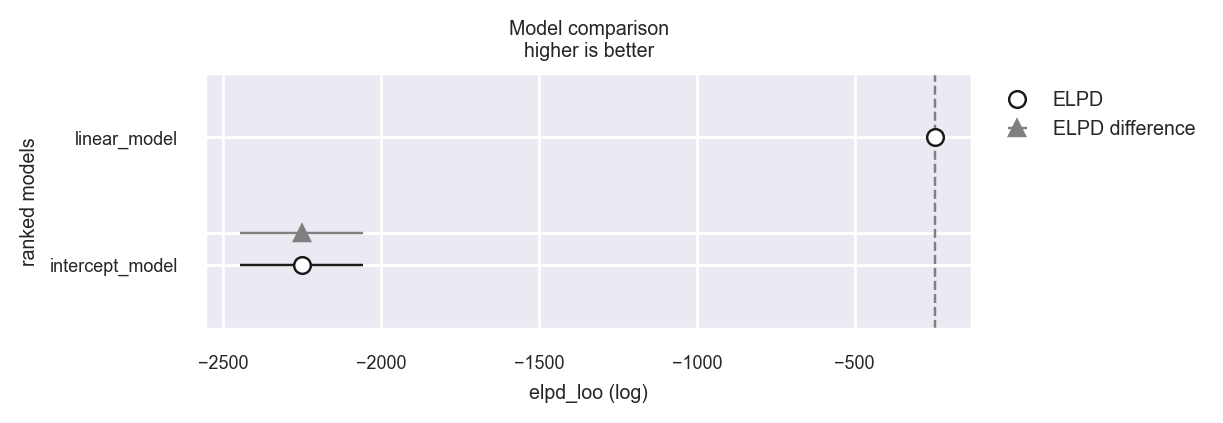

In [30]:
_ = az.plot_compare(df_comp_loo, insample_dev=False)

## Riflessioni Conclusive 

In questo capitolo, abbiamo approfondito il metodo della Validazione Incrociata Leave-One-Out (LOO-CV) come strumento efficace per stimare l'Expected Log Predictive Density (ELPD). Abbiamo illustrato in dettaglio come la LOO-CV possa essere applicata utilizzando il framework PyMC, evidenziando il suo ruolo cruciale nella pratica della modellazione statistica.

Un aspetto centrale che abbiamo esaminato è l'importanza della LOO-CV nel contesto del confronto tra diversi modelli statistici. Questo metodo non solo aiuta a valutare la capacità predittiva di un singolo modello, ma si rivela anche essenziale quando si tratta di selezionare il modello più adatto tra un insieme di alternative, fornendo una base di confronto oggettiva e affidabile.

Inoltre, abbiamo discusso il ruolo significativo dei valori diagnostici Pareto $k$ nell'interpretazione delle stime ottenute tramite LOO-CV. Abbiamo sottolineato come questi valori siano fondamentali per valutare l'affidabilità delle stime di ELPD derivate dalla LOO-CV, offrendo una misura della precisione e della robustezza di queste stime.

Nel complesso, attraverso questo capitolo, abbiamo mirato a fornire una comprensione completa di come la LOO-CV e i valori diagnostici Pareto $k$ siano impiegati per migliorare la precisione e l'affidabilità delle stime di ELPD, migliorando così la qualità e l'efficacia dei modelli statistici in vari contesti di ricerca e applicazione.

## Watermark

In [31]:
%load_ext watermark
%watermark -n -u -v -iv -w -p jax

Last updated: Wed Feb 21 2024

Python implementation: CPython
Python version       : 3.11.7
IPython version      : 8.21.0

jax: 0.4.23

pymc       : 5.10.4
pandas     : 2.2.0
statsmodels: 0.14.1
numpy      : 1.26.4
arviz      : 0.17.0
scipy      : 1.12.0
seaborn    : 0.13.2
matplotlib : 3.8.2

Watermark: 2.4.3

